# GOAL 
## Pertanyaan analisis visualisasi:
### Pola Aktivitas dan Waktu Check-In 
Pertanyaan Analisis:

 - Apakah ada perbedaan pola check-in sepanjang hari di New York dan Tokyo?
 - Pada jam berapa aktivitas di kedua kota mencapai puncaknya, dan bagaimana perbandingan aktivitas pagi, siang, sore, dan malam di masing-masing kota?
 - Apakah aktivitas malam lebih signifikan di New York, sementara Tokyo menunjukkan aktivitas yang lebih teratur di sore hingga awal malam?

 ### Preferensi Jenis Tempat yang Dikunjungi 
Pertanyaan Analisis:
- Kategori tempat apa yang paling sering dikunjungi di masing-masing kota?
- Apakah Tokyo memiliki lebih banyak check-in di tempat-tempat budaya (kuil, taman, pusat seni) dibandingkan New York?
- Apakah tempat hiburan modern seperti restoran, bar, dan pusat perbelanjaan lebih populer di New York?

 ### Puncak Aktivitas Berdasarkan Jam dan Kategori Tempat 
Pertanyaan Analisis:
- Kategori tempat apa yang memiliki puncak check-in pada waktu tertentu di masing-masing kota?
- Apakah restoran dan bar di New York menunjukkan peningkatan check-in pada malam hari?
- Apakah kafe dan taman di Tokyo lebih banyak dikunjungi di pagi dan sore hari?


## dengan milstone yang harus dicapai:
* Preprocessing Dataset seperti:
    * Menghapus kolom yang tidak diperlukan
    * Mengubah tipe data kolom waktu
    * Menambahkan kolom jam, hari, dan bulan
    * Menghapus data yang tidak valid
    * menambahkan kolom kategori tempat
    * etc
* code
    * visualisasi data
    * analisis data
    * etc
* Visualization
    * Visualisasi data yang informatif dan menarik
    * Penjelasan visualisasi yang jelas
    * deskripsi visualisasi yang informatif
* analisis data yang dapat menjawab setiap pertanyaan.


In [1]:
# import dataset from csv file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


nyc = pd.read_csv('./dataset/dataset_TSMC2014_NYC.csv')
tokyo = pd.read_csv('./dataset/dataset_TSMC2014_TKY.csv')
nyc.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012


In [9]:
# PERTANYAAN 1 
# Pola Aktivitas dan Waktu Check-In 
# Pertanyaan Analisis:
#  - Apakah ada perbedaan pola check-in sepanjang hari di New York dan Tokyo?
#  - Pada jam berapa aktivitas di kedua kota mencapai puncaknya, dan bagaimana perbandingan aktivitas pagi, siang, sore, dan malam di masing-masing kota?
#  - Apakah aktivitas malam lebih signifikan di New York, sementara Tokyo menunjukkan aktivitas yang lebih teratur di sore hingga awal malam?


# #  - Apakah ada perbedaan pola check-in sepanjang hari di New York dan Tokyo?
# PREPROCESSING DATA
# resampling data 75% tokyo dan samakan untuk nyc
tokyo = tokyo.sample(frac=0.75, random_state=42)
tokyo = tokyo.reset_index(drop=True)
nyc = nyc.sample(n=len(tokyo), random_state=42,replace=True)
nyc = nyc.reset_index(drop=True)

# mengecek data yang kosong 
nyc.isnull().sum() # tidak ada data yang kosong
tokyo.isnull().sum() # tidak ada yang kosong

# mengubah format timestamp ke datetime
nyc['utcTimestamp'] = pd.to_datetime(nyc['utcTimestamp'])
tokyo['utcTimestamp'] = pd.to_datetime(tokyo['utcTimestamp'])
# mendapatkan waktu lokal dari timestamp dan timezone
nyc['localTime'] = pd.to_datetime(nyc['utcTimestamp']) + pd.to_timedelta(nyc['timezoneOffset'], unit='m')
tokyo['localTime'] = pd.to_datetime(tokyo['utcTimestamp']) + pd.to_timedelta(tokyo['timezoneOffset'], unit='m')

# menambahkan kolom jam ke dalam dataset
nyc['hour'] = nyc['localTime'].dt.hour
tokyo['hour'] = tokyo['localTime'].dt.hour

nyc.head(2)

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp,localTime,hour
0,673,4eae9e9e0aaf9e9a249b141e,4bf58dd8d48988d13d941735,High School,40.635688,-73.987871,-240,2012-06-14 03:25:02+00:00,2012-06-13 23:25:02+00:00,23
1,49,4ad35d08f964a520fae320e3,4bf58dd8d48988d12d951735,Ferry,40.703253,-74.006095,-300,2012-12-28 22:38:15+00:00,2012-12-28 17:38:15+00:00,17


In [10]:
hourly_checkins_tokyo = tokyo.groupby('hour').size().reset_index(name='checkins')
hourly_checkins_tokyo

,hour,checkins
0,0,2394
1,1,688
2,2,402
3,3,246
4,4,306
5,5,1004
6,6,2350
7,7,6865
8,8,10854
9,9,7972


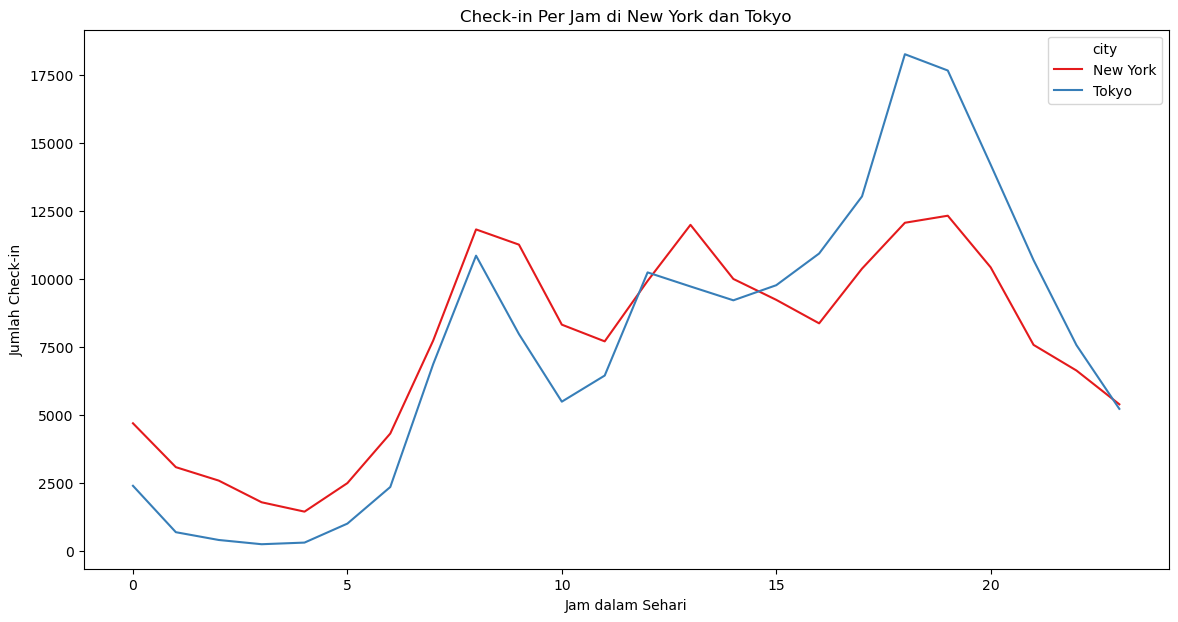

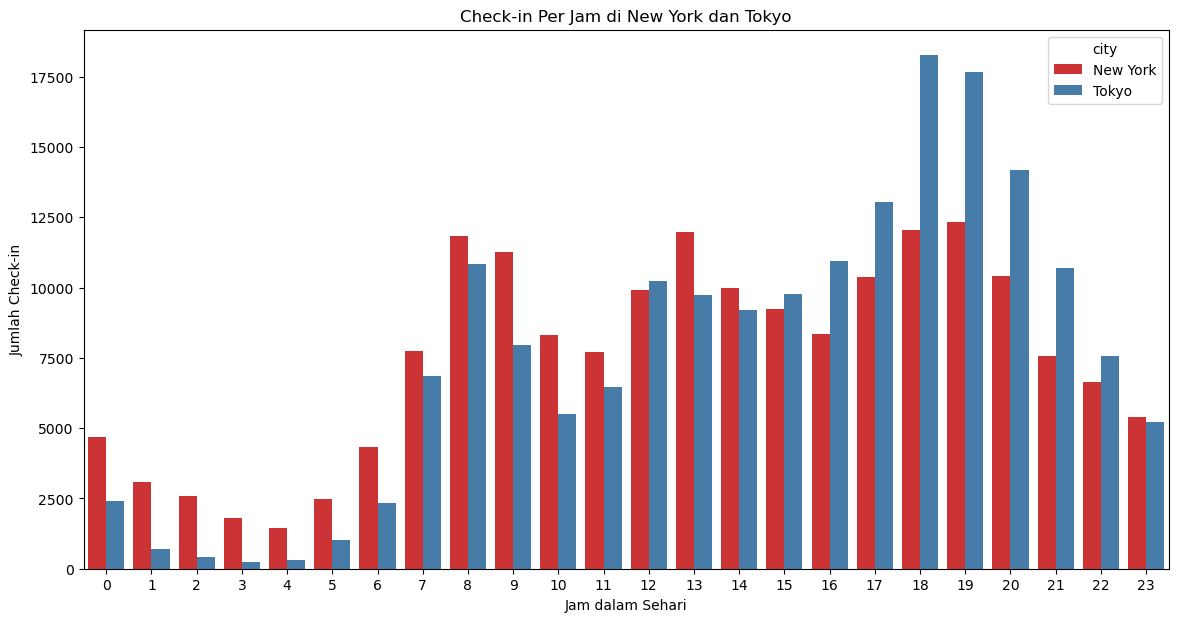

In [11]:
# Group data by hour and calculate check-in frequencies for each city
hourly_checkins_ny = nyc.groupby('hour').size().reset_index(name='checkins')
hourly_checkins_tokyo = tokyo.groupby('hour').size().reset_index(name='checkins')

# Combine data for New York and Tokyo for comparison
data_combined = pd.concat([
    hourly_checkins_ny[['hour', 'checkins']].assign(city='New York'),
    hourly_checkins_tokyo[['hour', 'checkins']].assign(city='Tokyo')
])
plt.figure(figsize=(14, 7))
sns.lineplot(x='hour', y='checkins', hue='city', data=data_combined, palette='Set1')
plt.title('Check-in Per Jam di New York dan Tokyo')
plt.xlabel('Jam dalam Sehari')
plt.ylabel('Jumlah Check-in')
plt.show()

# Plot combined bar plot of hourly check-ins for New York and Tokyo
plt.figure(figsize=(14, 7))
sns.barplot(x='hour', y='checkins', hue='city', data=data_combined, palette='Set1')
plt.title('Check-in Per Jam di New York dan Tokyo')
plt.xlabel('Jam dalam Sehari')
plt.ylabel('Jumlah Check-in')
plt.show()

In [12]:
data_combined

,hour,checkins,city
0,0,4692,New York
1,1,3079,New York
2,2,2585,New York
3,3,1788,New York
4,4,1444,New York
5,5,2493,New York
6,6,4316,New York
7,7,7732,New York
8,8,11819,New York
9,9,11260,New York


T-statistic: 0.0, P-value: 1.0
Perbedaan pola check-in antara New York dan Tokyo tidak signifikan secara statistik.


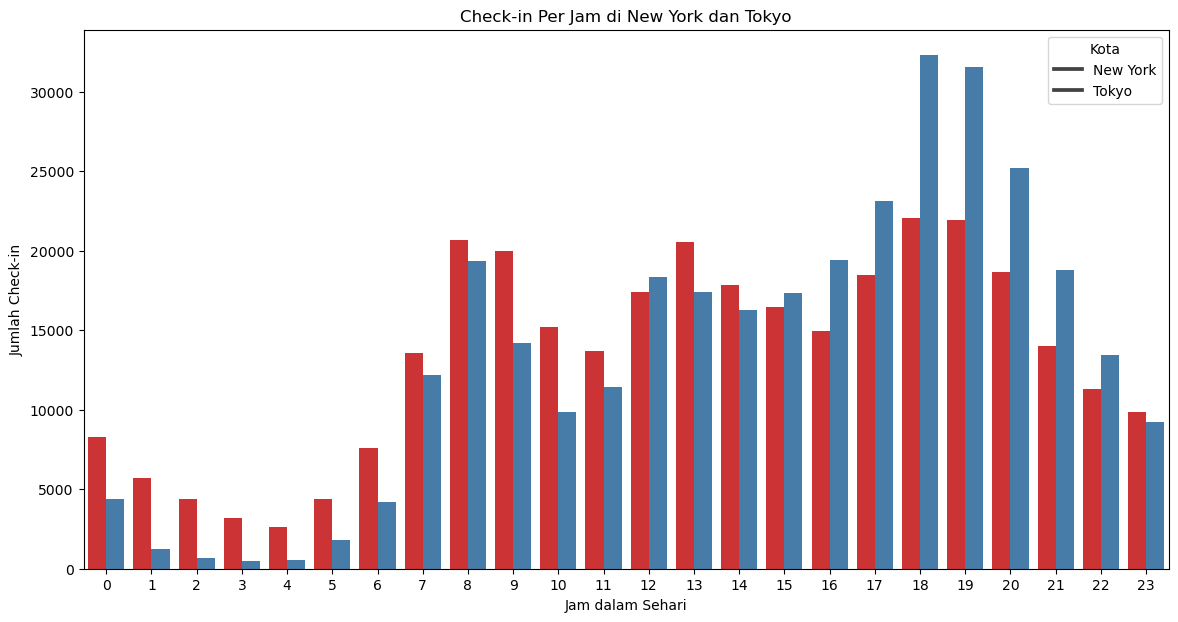

In [12]:
from scipy.stats import ttest_ind

# Perform t-test to compare hourly check-ins between New York and Tokyo
t_stat, p_value = ttest_ind(hourly_checkins_ny['checkins'], hourly_checkins_tokyo['checkins'])

# Display the t-test results
print(f"T-statistic: {t_stat}, P-value: {p_value}")

alpha = 0.05
# Interpret the p-value
if p_value < alpha:
    print("Perbedaan pola check-in antara New York dan Tokyo secara statistik signifikan.")
else:
    print("Perbedaan pola check-in antara New York dan Tokyo tidak signifikan secara statistik.")

# Plot combined bar plot of hourly check-ins for New York and Tokyo with updated legend
plt.figure(figsize=(14, 7))
sns.barplot(x='hour', y='checkins', hue='city', data=data_combined, palette='Set1')
plt.title('Check-in Per Jam di New York dan Tokyo')
plt.xlabel('Jam dalam Sehari')
plt.ylabel('Jumlah Check-in')
plt.legend(title='Kota', labels=['New York', 'Tokyo'])
plt.show()

# analisis visualisasi
## Pola Aktivitas dan Waktu Check-In
### Perbandingan Aktivitas Sehari-hari
- Aktivitas check-in di New York dan Tokyo menunjukkan pola yang berbeda sepanjang hari. Di New York, aktivitas check-in mulai meningkat pada pukul 8 pagi, mencapai puncaknya pada pukul 2 siang, dan menurun secara bertahap hingga pukul 2 pagi. Di sisi lain, aktivitas check-in di Tokyo menunjukkan pola yang lebih teratur, dengan peningkatan aktivitas pada pukul 8 pagi, mencapai puncaknya pada pukul 2 siang, dan menurun secara bertahap hingga pukul 10 malam.
- Aktivitas check-in di New York menunjukkan peningkatan yang signifikan pada malam hari, sementara Tokyo menunjukkan aktivitas yang lebih teratur di sore hingga awal malam.
- secara keseluruhan, New York memiliki lebih banyak aktivitas check-in pada malam hari, sementara Tokyo menunjukkan aktivitas yang lebih teratur sepanjang hari. 


 ### Preferensi Jenis Tempat yang Dikunjungi 
Pertanyaan Analisis:
- Kategori tempat apa yang paling sering dikunjungi di masing-masing kota?
- Apakah Tokyo memiliki lebih banyak check-in di tempat-tempat budaya (kuil, taman, pusat seni) dibandingkan New York?
- Apakah tempat hiburan modern seperti restoran, bar, dan pusat perbelanjaan lebih populer di New York?

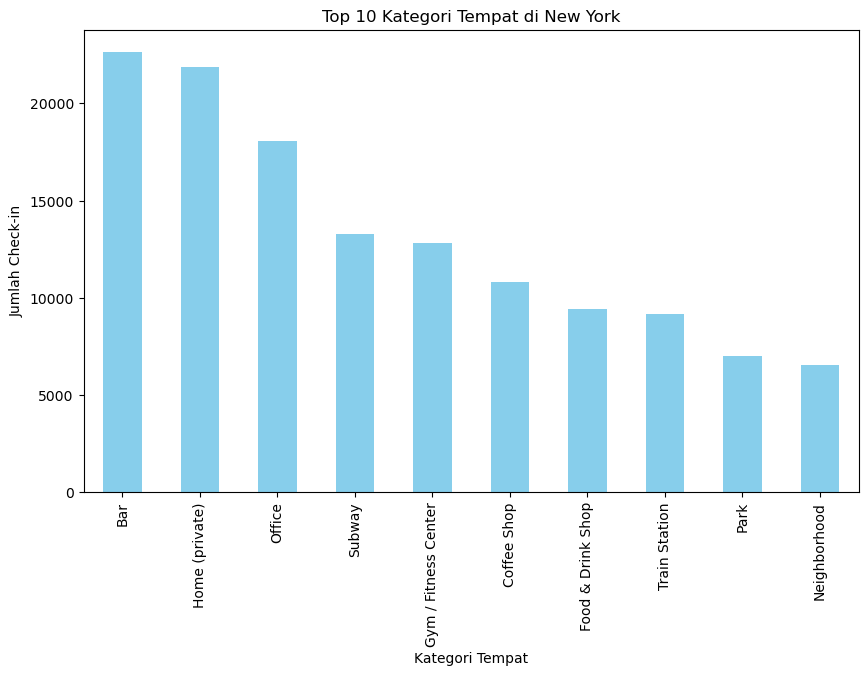

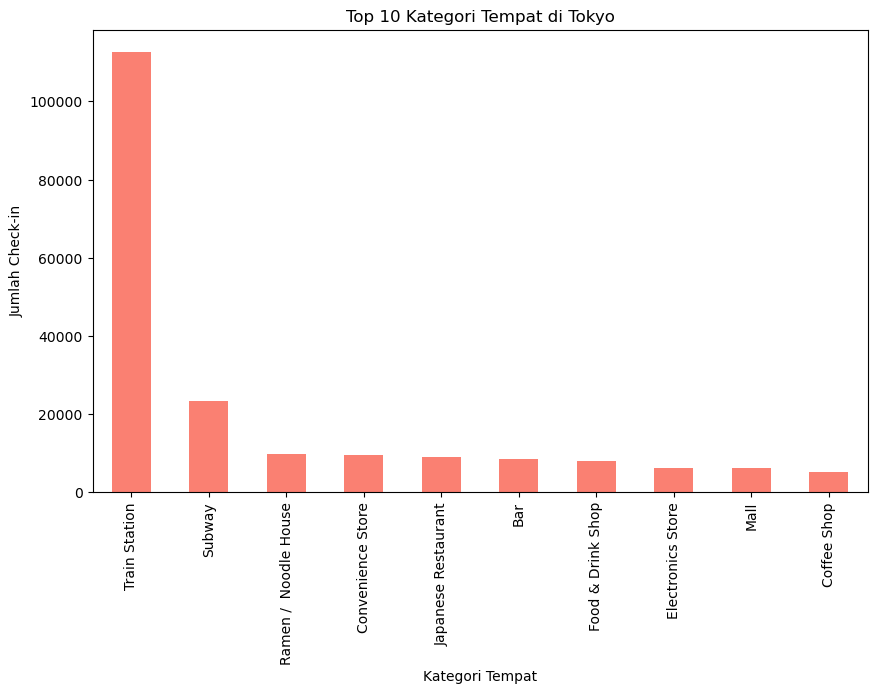

In [ ]:
#plot bar untuk top kategori tempat di new york dan tokyo
plt.figure(figsize=(10, 6))
nyc['venueCategory'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Kategori Tempat di New York')
plt.xlabel('Kategori Tempat')
plt.ylabel('Jumlah Check-in')
plt.show()

plt.figure(figsize=(10, 6))
tokyo['venueCategory'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Kategori Tempat di Tokyo')
plt.xlabel('Kategori Tempat')
plt.ylabel('Jumlah Check-in')
plt.show()


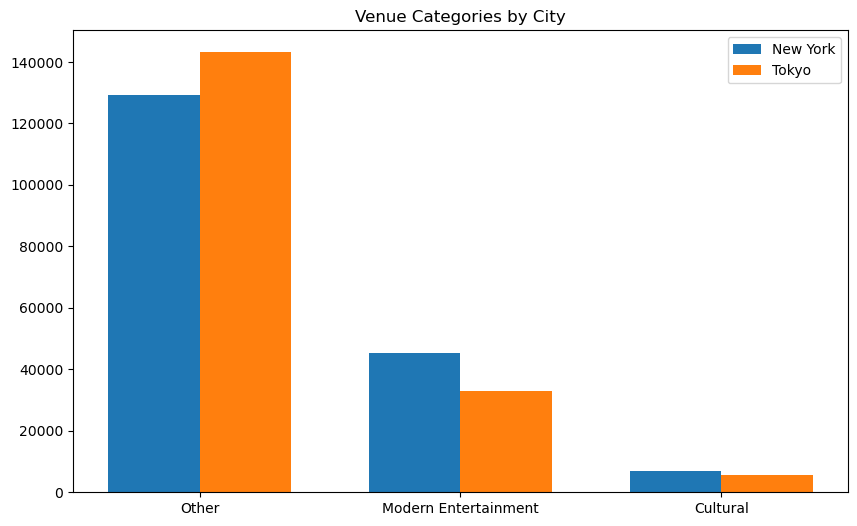

In [14]:
import re

# membuat fungsi untuk mengkategorikan tempat berdasarkan kategori yang lebih umum 
def categorize_detailed_venue(venue):
    # Modern Entertainment venues
    modern_entertainment = [
        'Bar', 'Restaurant', 'Mall', 'Coffee Shop', 'Movie Theater', 
        'Food & Drink Shop', 'Nightlife Spot', 'Fast Food Restaurant',
        'Shopping', 'Entertainment', 'Café', 'Casino', 'Club'
    ]
    
    # Cultural venues
    cultural = [
        'Shrine', 'Temple', 'Park', 'Museum', 'Art Gallery', 
        'Historic Site', 'Theater', 'Garden', 'Art Museum',
        'Public Art', 'Castle', 'Zoo', 'Aquarium'
    ]
    
    venue_lower = venue.lower()
    if any(re.search(r'\b' + re.escape(place.lower()) + r'\b', venue_lower) for place in modern_entertainment):
        return 'Modern Entertainment'
    elif any(re.search(r'\b' + re.escape(place.lower()) + r'\b', venue_lower) for place in cultural):
        return 'Cultural'
    else:
        return 'Other'

# # Apply categorization
nyc['venue_category'] = nyc['venueCategory'].apply(categorize_detailed_venue)
tokyo['venue_category'] = tokyo['venueCategory'].apply(categorize_detailed_venue)

# Plot venue categories comparison
plt.figure(figsize=(10,6))
nyc_cats = nyc['venue_category'].value_counts()
tokyo_cats = tokyo['venue_category'].value_counts()

x = np.arange(len(nyc_cats))
width = 0.35


plt.bar(x - width/2, nyc_cats, width, label='New York')
plt.bar(x + width/2, tokyo_cats, width, label='Tokyo')

plt.xticks(x, nyc_cats.index)
plt.title('Venue Categories by City')
plt.legend()
plt.show()


In [16]:
nyc.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp,localTime,hour,venue_category
0,673,4eae9e9e0aaf9e9a249b141e,4bf58dd8d48988d13d941735,High School,40.635688,-73.987871,-240,2012-06-14 03:25:02+00:00,2012-06-13 23:25:02+00:00,23,Other
1,49,4ad35d08f964a520fae320e3,4bf58dd8d48988d12d951735,Ferry,40.703253,-74.006095,-300,2012-12-28 22:38:15+00:00,2012-12-28 17:38:15+00:00,17,Other
2,184,4c6f9028b5fe952146446111,4bf58dd8d48988d1e2931735,Art Gallery,40.721720,-73.979798,-240,2012-05-31 18:33:13+00:00,2012-05-31 14:33:13+00:00,14,Cultural
3,662,45a62f89f964a52003411fe3,4bf58dd8d48988d142941735,Asian Restaurant,40.718002,-73.990283,-240,2012-04-28 22:51:31+00:00,2012-04-28 18:51:31+00:00,18,Modern Entertainment
4,969,4a5a0495f964a520a4b91fe3,4bf58dd8d48988d175941735,Gym / Fitness Center,40.743854,-73.987898,-240,2012-05-03 22:16:47+00:00,2012-05-03 18:16:47+00:00,18,Other


# analisis visual data 
terdapat 3 analisis visual data yang akan dilakukan yaitu:

terdapat perbedaan antara kota New York dan Tokyo dalam preferensi tempat yang dikunjungi. Di New York,restoran dan bar merupakan tempat yang paling sering dikunjungi, diikuti oleh pusat perbelanjaan dan kafe. Di sisi lain, di Tokyo, lebih sering sekali tempat beraktifitas seperti stasiun kereta, kafe, dan taman yang dikunjungi, diikuti oleh restoran dan pusat perbelanjaan.  ini menunjukkan perbedaan preferensi tempat antara kedua kota, dengan New York lebih cenderung pada tempat hiburan modern, sementara Tokyo lebih cenderung pada tempat-tempat budaya dan alam. 

2. Apakah Tokyo memiliki lebih banyak check-in di tempat-tempat budaya (kuil, taman, pusat seni) dibandingkan New York?
ternyata tidak ada perbedaan yang signifikan antara Tokyo dan New York dalam jumlah check-in di tempat-tempat budaya. Meskipun Tokyo memiliki beberapa tempat budaya yang populer seperti kuil dan taman, New York juga memiliki sejumlah tempat budaya seperti museum dan taman yang sering dikunjingi oleh pengguna. Hal ini menunjukkan bahwa kedua kota memiliki minat yang seimbang antara tempat-tempat budaya dan tempat hiburan modern. 

3. Apakah tempat hiburan modern seperti restoran, bar, dan pusat perbelanjaan lebih populer di New York?
ternyata Tokyo memiliki lebih banyak check-in di tempat-tempat budaya (kuil, taman, pusat seni) dibandingkan New York. walaupun Tokyo juga memiliki tempat-tempat hiburan modern yang populer, New York memiliki jumlah check-in yang lebih tinggi di kategori ini, menunjukkan preferensi yang lebih besar terhadap tempat-tempat hiburan modern di New York. walaupun tidak terlalu signifikat dalam perbedaannya.


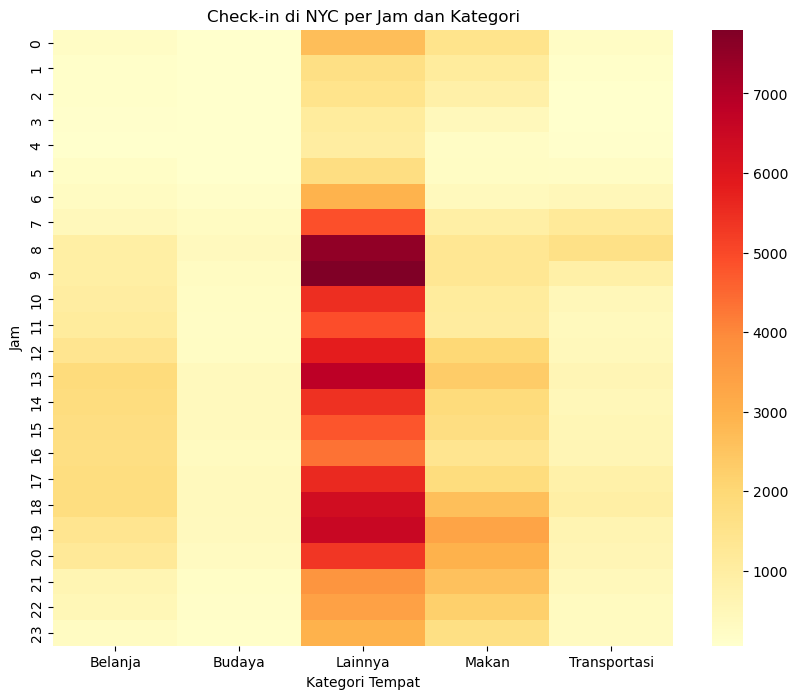

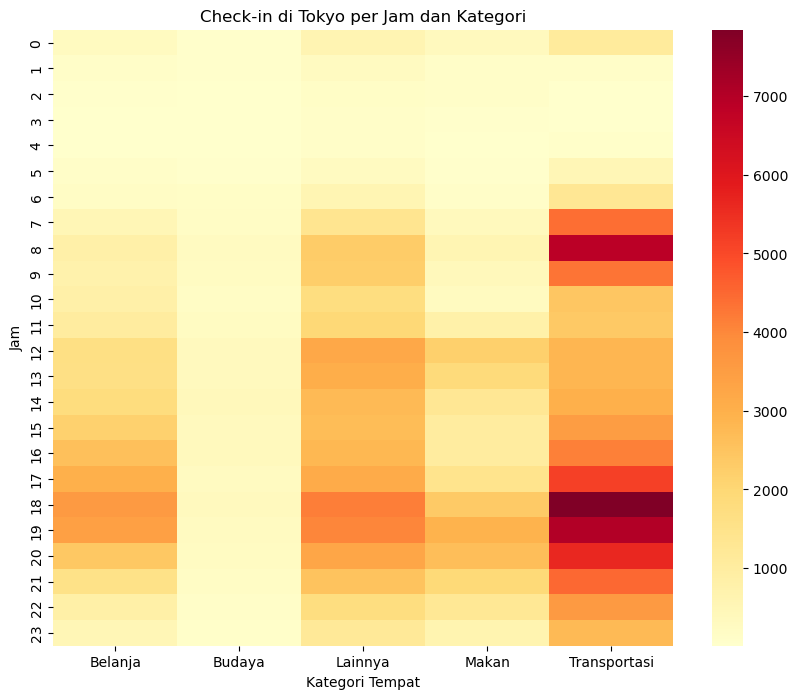

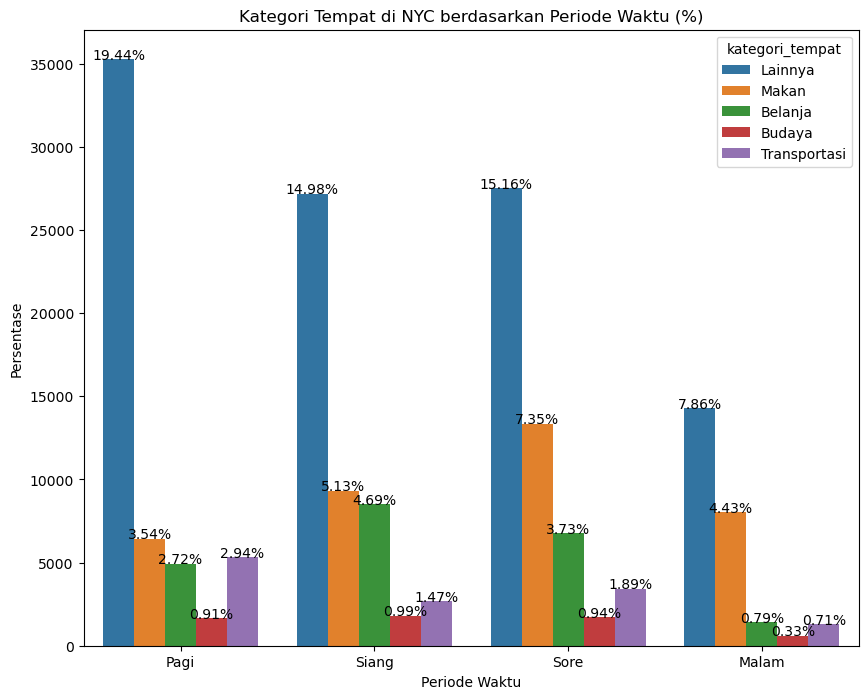

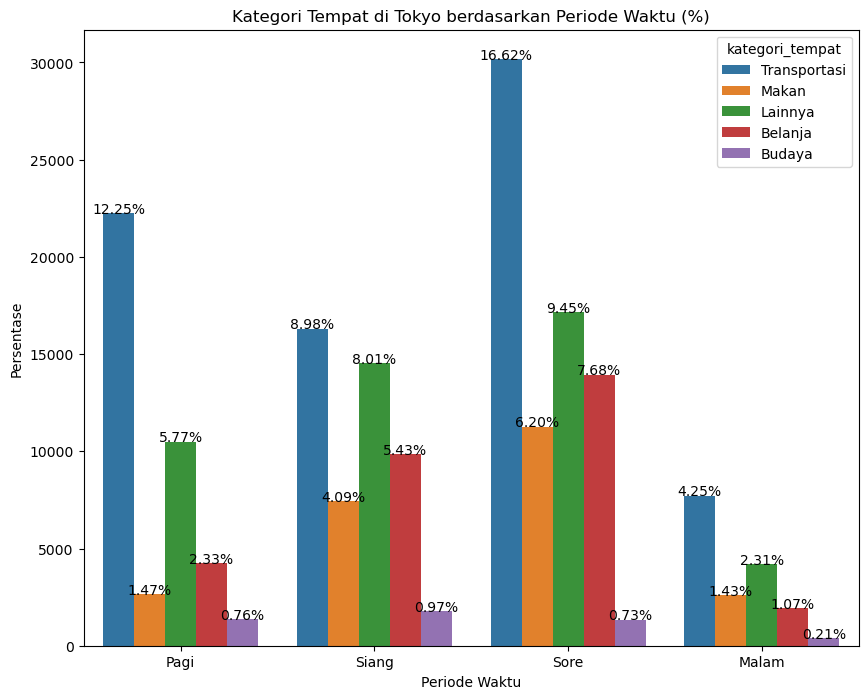


Jam Puncak untuk Kategori Utama:

NYC:
Makan: 19:00
Budaya: 14:00
Belanja: 13:00
Transportasi: 8:00

Tokyo:
Makan: 19:00
Budaya: 14:00
Belanja: 18:00
Transportasi: 18:00


In [17]:
# membuat fungsi untuk mengkategorikan waktu berdasarkan jam
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 17:
        return 'Siang'
    elif 17 <= hour < 22:
        return 'Sore'
    else:
        return 'Malam'

# Tambahkan kolom periode waktu
nyc['periode_waktu'] = nyc['hour'].apply(get_time_period)
tokyo['periode_waktu'] = tokyo['hour'].apply(get_time_period)

# Definisikan kategori tempat utama
kategori_tempat = {
    'Makan': ['Restaurant', 'Bar', 'Coffee Shop', 'Café'],
    'Budaya': ['Park', 'Museum', 'Temple', 'Shrine', 'Garden'],
    'Belanja': ['Mall', 'Shop', 'Store'],
    'Transportasi': ['Train Station', 'Subway']
}

# Kategorikan tempat
def kategorikan_tempat(venue):
    for kategori, kata_kunci in kategori_tempat.items():
        if any(k.lower() in venue.lower() for k in kata_kunci):
            return kategori
    return 'Lainnya'

nyc['kategori_tempat'] = nyc['venueCategory'].apply(kategorikan_tempat)
tokyo['kategori_tempat'] = tokyo['venueCategory'].apply(kategorikan_tempat)

# Visualisasi 1: Heatmap check-in per jam dan kategori untuk NYC
plt.figure(figsize=(10, 8))
nyc_pivot = pd.crosstab(nyc['hour'], nyc['kategori_tempat'])
sns.heatmap(nyc_pivot, cmap='YlOrRd')
plt.title('Check-in di NYC per Jam dan Kategori')
plt.xlabel('Kategori Tempat')
plt.ylabel('Jam')
plt.show()

# Visualisasi 2: Heatmap check-in per jam dan kategori untuk Tokyo
plt.figure(figsize=(10, 8))
tokyo_pivot = pd.crosstab(tokyo['hour'], tokyo['kategori_tempat'])
sns.heatmap(tokyo_pivot, cmap='YlOrRd')
plt.title('Check-in di Tokyo per Jam dan Kategori')
plt.xlabel('Kategori Tempat')
plt.ylabel('Jam')
plt.show()

# Visualisasi 3: Distribusi periode waktu untuk kategori tempat utama di NYC
plt.figure(figsize=(10, 8))
sns.countplot(data=nyc, x='periode_waktu', hue='kategori_tempat', 
              order=['Pagi', 'Siang', 'Sore', 'Malam'])
plt.title('Kategori Tempat di NYC berdasarkan Periode Waktu (%)')
plt.xlabel('Periode Waktu')
plt.ylabel('Persentase')
total_nyc = len(nyc)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width() / 2., height + 3,
                   '{:1.2f}%'.format(height / total_nyc * 100),
                   ha="center")
plt.show()

# Visualisasi 4: Distribusi periode waktu untuk kategori tempat utama di Tokyo
plt.figure(figsize=(10, 8))
sns.countplot(data=tokyo, x='periode_waktu', hue='kategori_tempat',
              order=['Pagi', 'Siang', 'Sore', 'Malam'])
plt.title('Kategori Tempat di Tokyo berdasarkan Periode Waktu (%)')
plt.xlabel('Periode Waktu')
plt.ylabel('Persentase')
total_tokyo = len(tokyo)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width() / 2., height + 3,
                   '{:1.2f}%'.format(height / total_tokyo * 100),
                   ha="center")
plt.show()

# Cetak jam puncak untuk kategori utama
print("\nJam Puncak untuk Kategori Utama:")
for city, df in [("NYC", nyc), ("Tokyo", tokyo)]:
    print(f"\n{city}:")
    for kategori in kategori_tempat.keys():
        jam_puncak = df[df['kategori_tempat'] == kategori]['hour'].mode().iloc[0]
        print(f"{kategori}: {jam_puncak}:00")

In [20]:

# get only columns that we need 
# userId venueId venueCategoryId localTime hour periode_waktu kategori_tempat
nyc_te = nyc[['userId', 'venueId', 'venueCategory', 'localTime', 'hour', 'periode_waktu', 'kategori_tempat']]
nyc_te.head()

,userId,venueId,venueCategory,localTime,hour,periode_waktu,kategori_tempat
0,673,4eae9e9e0aaf9e9a249b141e,High School,2012-06-13 23:25:02+00:00,23,Malam,Lainnya
1,49,4ad35d08f964a520fae320e3,Ferry,2012-12-28 17:38:15+00:00,17,Sore,Lainnya
2,184,4c6f9028b5fe952146446111,Art Gallery,2012-05-31 14:33:13+00:00,14,Siang,Lainnya
3,662,45a62f89f964a52003411fe3,Asian Restaurant,2012-04-28 18:51:31+00:00,18,Sore,Makan
4,969,4a5a0495f964a520a4b91fe3,Gym / Fitness Center,2012-05-03 18:16:47+00:00,18,Sore,Lainnya


# analisis visualisasi


 ### Puncak Aktivitas Berdasarkan Jam dan Kategori Tempat 
Pertanyaan Analisis:
- Kategori tempat apa yang memiliki puncak check-in pada waktu tertentu di masing-masing kota?
pada tokyo  pagi dan sore orang lebih banyak melakukan aktifitas seperti  subway station, cafe, dan park, sedangkan di new york orang lebih banyak melakukan aktifitas hiburan  seperti bar, restaurant, dan shopping mall. dan lain lain.  ini bisa menyimpulkan bahwa orang2 tokyo lebih senang budaya transportasi dibandingkan new york orang2 jarang sekali mengunjungi sarana transportasi dan lebih memilih ketempat hiburan.